# ViDA Adaptation on APTOS (RETFound DINOv2 ViT-L)
Homeostatic Visual Domain Adapter with dual-branch adapters and symmetric KL consistency loss.

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
config = load_config('configs/method/vida/aptos.yaml')

print('Dataset:', config.target_dataset.name)
print('Method:', config.ctta.method)
print('Output:', config.output_dir)

if config.model.name == 'retfound' and not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN set')
elif config.model.name != 'retfound':
    print('No HF token needed (VisionFM / Google Drive)')

Dataset: aptos2019
Method: vida
Output: ./outputs/vida/aptos/
HF_TOKEN set


In [4]:
from src.evaluation.runner import CTTARunner

runner = CTTARunner(config)
results = runner.run()

2026-08-05 08:40:19,343 - src.evaluation.runner.single - INFO - Starting CTTA adaptation on dataset: aptos2019
2026-08-05 08:40:23,930 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/YukunZhou/RETFound_dinov2_meh/resolve/main/RETFound_dinov2_meh.pth "HTTP/1.1 302 Found"
2026-08-05 08:40:24,067 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/YukunZhou/RETFound_dinov2_meh/xet-read-token/6dff4c76632983267a6ae3000f7852b1f8667d9c "HTTP/1.1 200 OK"


RETFound_dinov2_meh.pth:   0%|          | 0.00/1.61G [00:00<?, ?B/s]

2026-08-05 08:40:34,161 - src.models.retfound - INFO - Extracted state_dict from DINOv2 'teacher' key
2026-08-05 08:40:34,162 - src.models.retfound - INFO - Stripped 'backbone.' prefix from 359 state dict keys
2026-08-05 08:40:34,163 - src.models.retfound - INFO - RETFound checkpoint cached in CPU RAM
2026-08-05 08:40:34,303 - src.models.retfound - INFO - Feature normalization ENABLED in forward() (required for prototype classifier)
2026-08-05 08:40:34,950 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
2026-08-05 08:44:06,059 - src.evaluation.runner.base - INFO - Prototype weights scaled by T=100.0
2026-08-05 08:44:06,065 - src.evaluation.runner.base - INFO - Prototype classifier initialized from 2930 training samples (5 classes, 1024-dim features, T=100.0)
2026-08-05 08:44:06,120 - src.evaluation.runner.single - INFO - Classifier initialized with training-set prototypes
2026-08-05 08:44:06,122 - src.evaluation.runner.single - INFO - Evaluating baseline on apt

Adapting to aptos2019:   0%|          | 0/23 [00:00<?, ?it/s]

2026-08-05 08:44:53,090 - src.evaluation.runner.single - INFO -   Adapt step 0: loss=0.0021, kl=0.0021, ce=0.0196, conf=0.31, unc=0.5388, lam_low=0.461, lam_high=1.539, restored=0


...

Adapting to aptos2019:  96%|█████████▌| 22/23 [06:07<00:16, 16.64s/it, acc=0.8125, adaptations=22]

2026-08-05 08:50:57,890 - src.evaluation.runner.single - INFO -   Adapt step 22: loss=0.0781, kl=0.0781, ce=0.0194, conf=0.21, unc=0.4297, lam_low=0.570, lam_high=1.430, restored=0


Adapting to aptos2019: 100%|██████████| 23/23 [06:23<00:00, 16.65s/it, acc=0.5714, adaptations=23]

2026-08-05 08:50:58,817 - src.evaluation.runner.single - INFO - Evaluating after adaptation on aptos2019


2026-08-05 08:51:26,183 - src.evaluation.runner.single - INFO - Post-adaptation QWK: 0.7477
2026-08-05 08:51:26,185 - src.evaluation.runner.single - INFO - Adaptations: 23/23
2026-08-05 08:51:26,269 - src.evaluation.runner.base - INFO - Results saved to outputs/vida/aptos/ctta_results.json


In [5]:
print('=== Results ===')
print(f'Baseline QWK:        {results["baseline_metrics"]["qwk"]:.4f}')
print(f'Baseline Accuracy:   {results["baseline_metrics"]["overall_accuracy"]*100:.2f}%')
print(f'Post-adapt QWK:      {results["final_metrics"]["qwk"]:.4f}')
print(f'Post-adapt Accuracy: {results["final_metrics"]["overall_accuracy"]*100:.2f}%')
dr = results['domain_result']
print(f'Adaptations:          {dr["num_adaptations"]}/{dr["total_batches"]}')
print(f'Adaptation rate:      {results.get("adaptation_rate", 0)*100:.2f}%')

gap = results['final_metrics']['qwk'] - results['baseline_metrics']['qwk']
print(f'QWK change:           {gap:+.4f}')
acc_gap = results['final_metrics']['overall_accuracy'] - results['baseline_metrics']['overall_accuracy']
print(f'Accuracy change:      {acc_gap*100:+.2f}%')

=== Results ===
Baseline QWK:        0.7263
Baseline Accuracy:   64.21%
Post-adapt QWK:      0.7477
Post-adapt Accuracy: 64.48%
Adaptations:          23/23
Adaptation rate:      100.00%
QWK change:           +0.0215
Accuracy change:      +0.27%


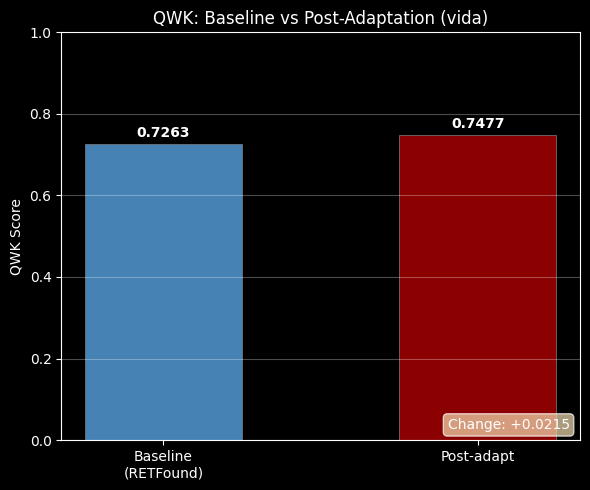

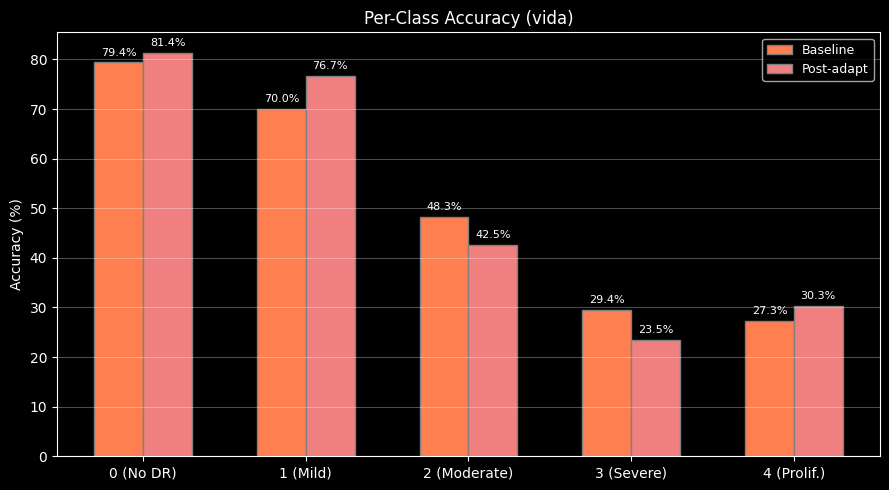

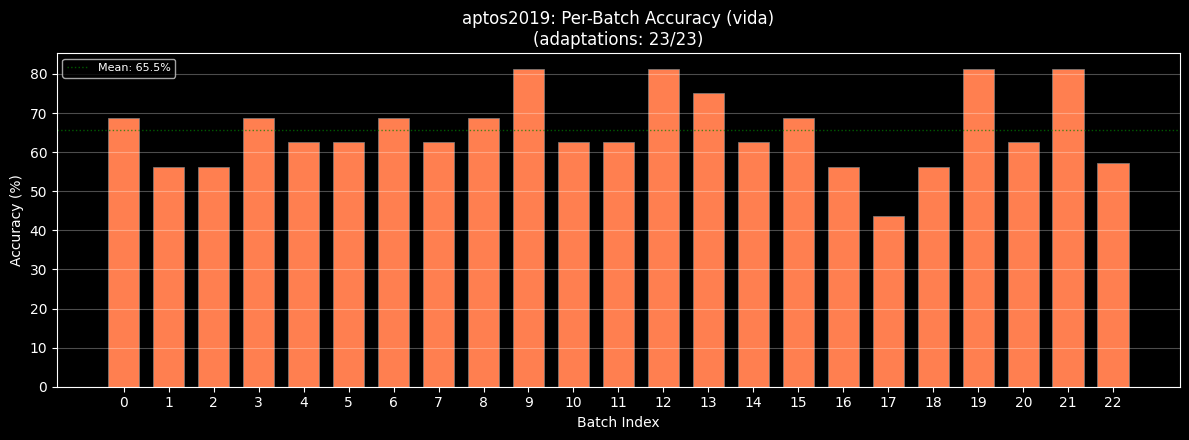

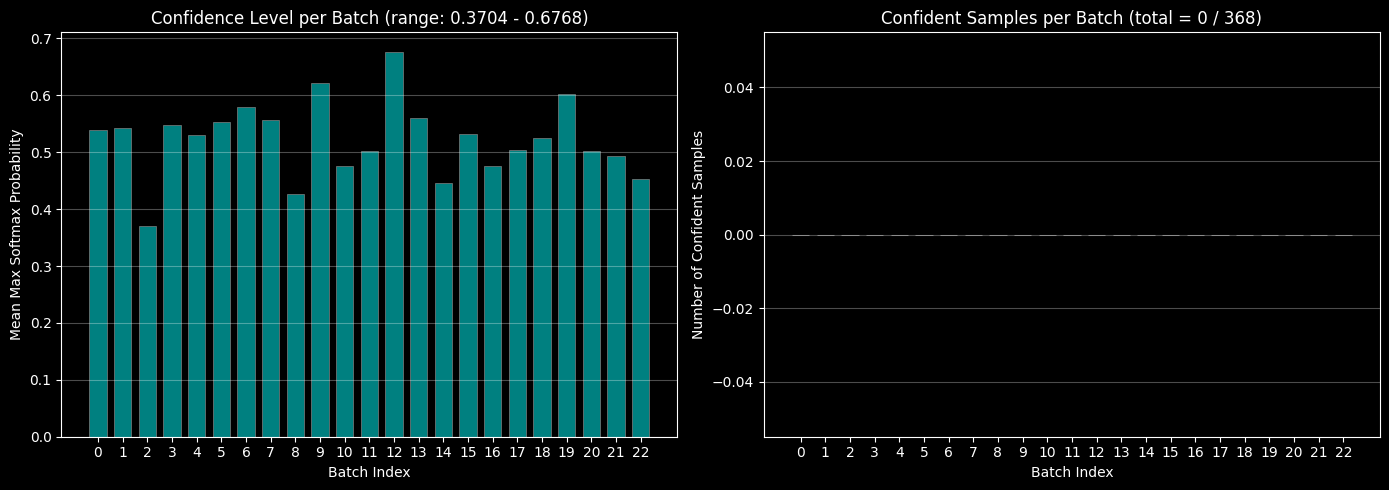

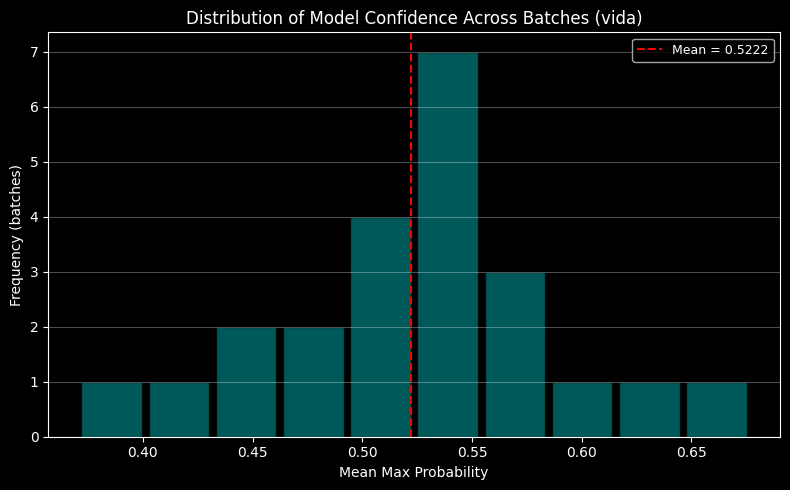

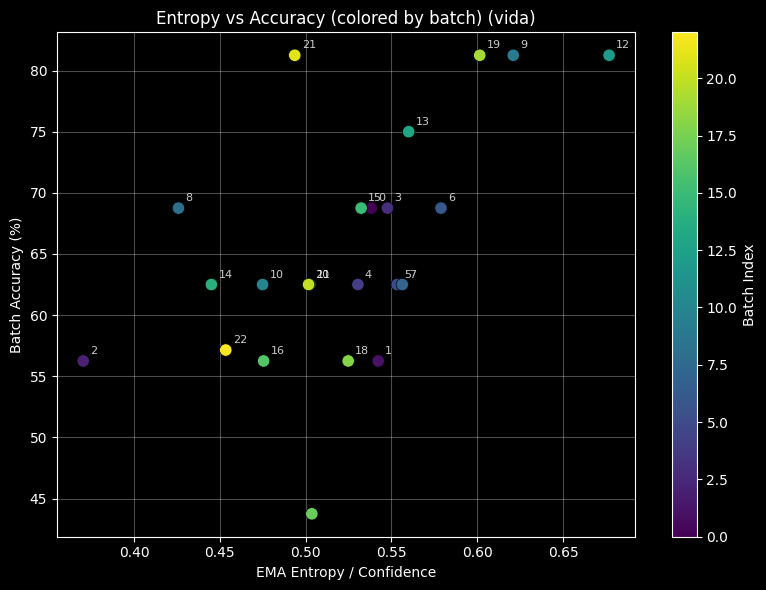

====================== CTTA Results (vida) ======================
Baseline QWK:       0.7263
Post-adapt QWK:     0.7477
Adaptations:        23/23
Adaptation rate:    100.00%
QWK change:         +0.0215
Mean batch acc:     65.5%


In [6]:
from src.viz import (
    get_domain_data, plot_qwk_bar, plot_per_batch_accuracy,
    plot_adaptation_metrics, plot_confidence_distribution,
    plot_entropy_vs_accuracy, print_summary_table, plot_per_class_accuracy as plot_pca,
)

import json
from pathlib import Path

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

with open(Path(config.output_dir) / 'ctta_results.json') as f:
    results = json.load(f)

dr = results['domain_result']
method = results.get("method", "")

plot_qwk_bar(results, plots_dir, method_name=method)
plot_pca(results, dr, plots_dir, method_name=method)
plot_per_batch_accuracy(dr, None, plots_dir, method_name=method)
plot_adaptation_metrics(dr['adaptation_steps'], plots_dir)
plot_confidence_distribution(dr['adaptation_steps'], plots_dir, method_name=method)
plot_entropy_vs_accuracy(dr['adaptation_steps'], dr['batch_metrics'], plots_dir, method_name=method)
print_summary_table(results, method_name=method)